# Lesson 2 : Image Data Types & Intensity Ranges (Deep Foundation)
This lesson is one of the most important foundations in image processing.
If you misunderstand this, many filters and segmentation results will behave strangely.

## What Is an Image Internally?

An image = **NumPy array**

Example:

In [1]:
from skimage import data

img = data.camera()
print(type(img))      # numpy.ndarray
print(img.shape)      # (512, 512)
print(img.dtype)      # uint8

<class 'numpy.ndarray'>
(512, 512)
uint8


So an image is just a matrix of numbers.

### Common Image Data Types

| Data Type | Range     | Bits   | Where Used         |
| --------- | --------- | ------ | ------------------ |
| uint8     | 0 → 255   | 8-bit  | Most common        |
| uint16    | 0 → 65535 | 16-bit | Medical images     |
| float     | 0.0 → 1.0 | 64-bit | skimage processing |

### What Does Range 0–255 Mean?

Example pixel:

```
0   → Black  
255 → White  
128 → Gray  
```
This is typical **uint8** image.

### What Does Range 0–1 Mean?

When converted to float:

```
0.0 → Black  
1.0 → White  
0.5 → Gray
```

Mathematically:
float_value = uint8_value / 255

### Why Does skimage Prefer 0–1?

Because:

* Mathematical operations are more stable
* No overflow problems
* More precision
* Filters assume normalized data

### Convert uint8 → float

In [2]:
from skimage import img_as_float

img_float = img_as_float(img)

### Convert float → uint8

In [3]:
from skimage import img_as_ubyte

img_uint8 = img_as_ubyte(img_float)

### Rescale Intensity
Rescale intensity means adjusting the brightness values (pixel intensities) of an image to a new range. This stretches pixel values to full range automatically.
#### Why is it needed?
Sometimes an image does not use the full brightness range.
For example:
- Image pixel values range from 80 to 150
- But the possible range is 0 to 255
- This means the image has low contrast.
- rescale_intensity() spreads those values across the full range, making the image clearer.

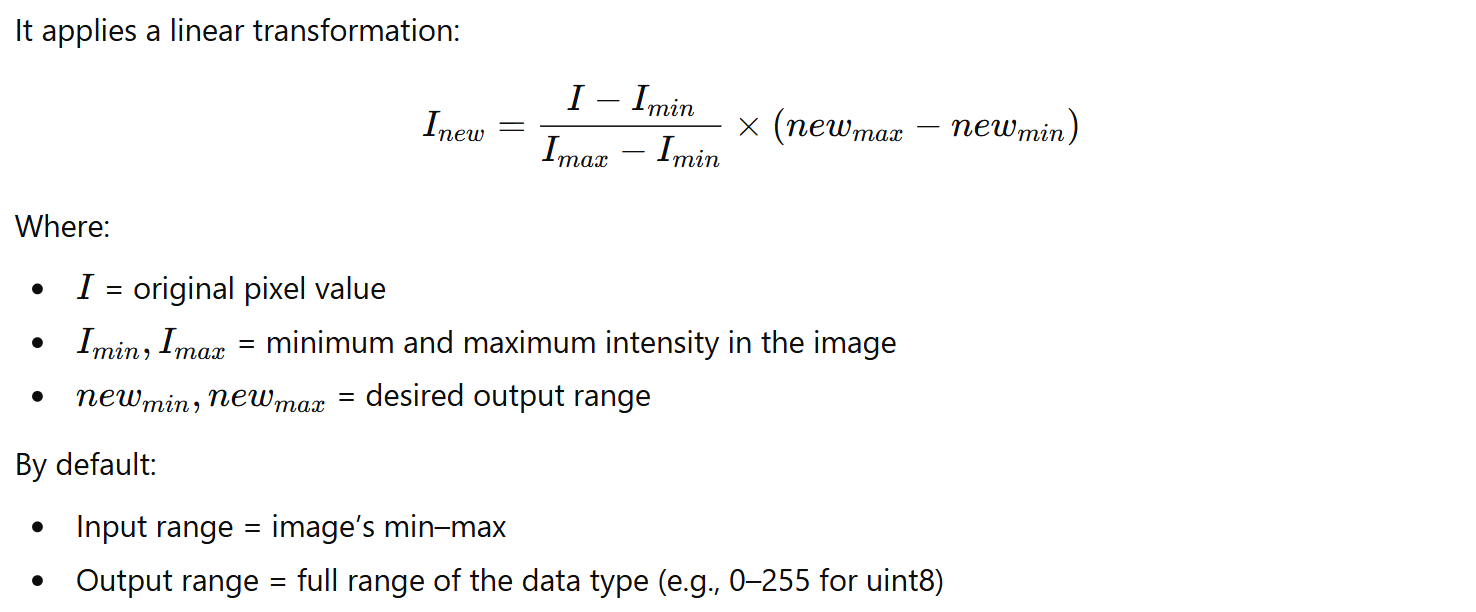

In [7]:
print("Minimum intensity:", img.min())
print("Maximum intensity:", img.max())

Minimum intensity: 0
Maximum intensity: 255


In [6]:
from skimage import exposure

rescaled = exposure.rescale_intensity(img)

rescaled

array([[200, 200, 200, ..., 189, 190, 190],
       [200, 199, 199, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190, 190],
       ...,
       [ 25,  25,  27, ..., 139, 122, 147],
       [ 25,  25,  26, ..., 158, 141, 168],
       [ 25,  25,  27, ..., 151, 152, 149]], dtype=uint8)

### Manual Control

In [8]:
rescaled = exposure.rescale_intensity(img, in_range=(50, 200))
rescaled

array([[255, 255, 255, ..., 236, 238, 238],
       [255, 253, 253, ..., 238, 238, 238],
       [253, 253, 253, ..., 238, 238, 238],
       ...,
       [  0,   0,   0, ..., 151, 122, 164],
       [  0,   0,   0, ..., 183, 154, 200],
       [  0,   0,   0, ..., 171, 173, 168]], dtype=uint8)

Meaning:
* Pixels < 50 → become 0
* Pixels > 200 → become 255
* Others stretched

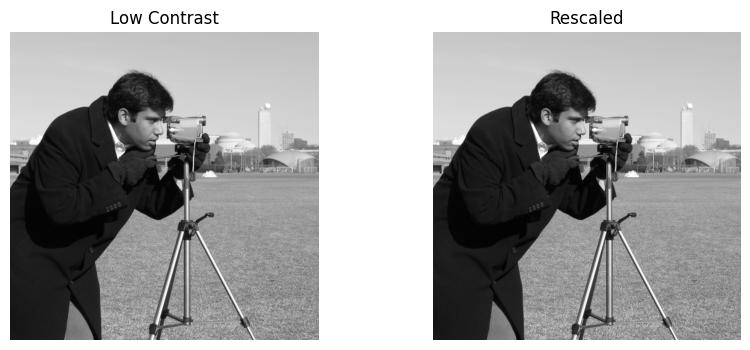

In [14]:
from skimage import data, exposure
import matplotlib.pyplot as plt

img = data.camera()

low = img / 3

rescaled = exposure.rescale_intensity(low)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(low, cmap='gray')
plt.title("Low Contrast")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rescaled, cmap='gray')
plt.title("Rescaled")
plt.axis("off")

plt.show()